# Customer Churn Prediction

Predicting which customers are going to cancel their subscription using the IBM Telco Customer Churn dataset (7043 customers, 21 features).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data cleaning

TotalCharges is an object column instead of numeric. Turns out some rows just have blank strings there instead of a number. These are all customers with tenure = 0, so basically new customers who havent been billed yet.

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isna().sum()

np.int64(11)

In [6]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])

## Exploratory data analysis

In [8]:
churn_rate = df["Churn"].value_counts(normalize=True)
churn_rate

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

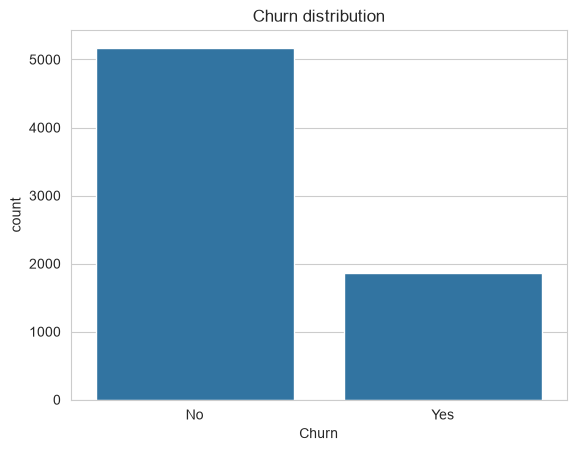

In [9]:
sns.countplot(data=df, x="Churn")
plt.title("Churn distribution")
plt.savefig("../results/churn_distribution.png", bbox_inches="tight")
plt.show()

About 27% of customers churned, so the classes are pretty imbalanced. A model that just predicts "No" every time would already be 73% accurate without doing anything useful, keep that in mind for evaluation later.

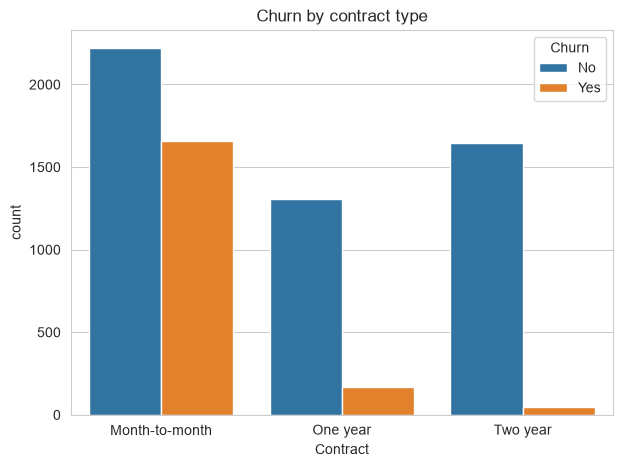

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by contract type")
plt.savefig("../results/churn_by_contract.png", bbox_inches="tight")
plt.show()

Month to month customers churn a lot more than customers with a 1 or 2 year contract. Makes sense, no penalty for leaving, so this is probably gonna be one of the strongest predictors.

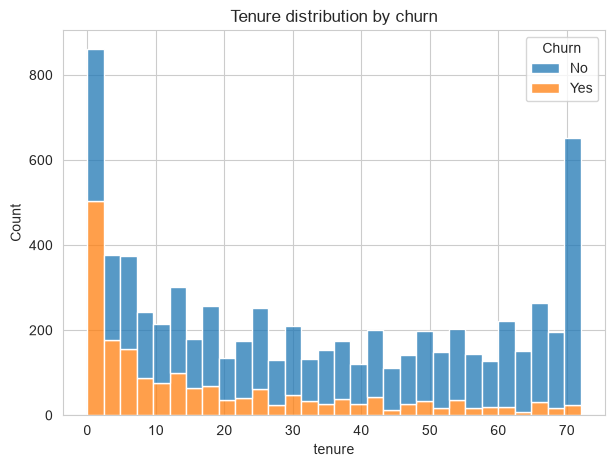

In [11]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack")
plt.title("Tenure distribution by churn")
plt.savefig("../results/tenure_by_churn.png", bbox_inches="tight")
plt.show()

Most churn happens in the first few months. After a customer sticks around for a year or so they seem a lot less likely to leave.

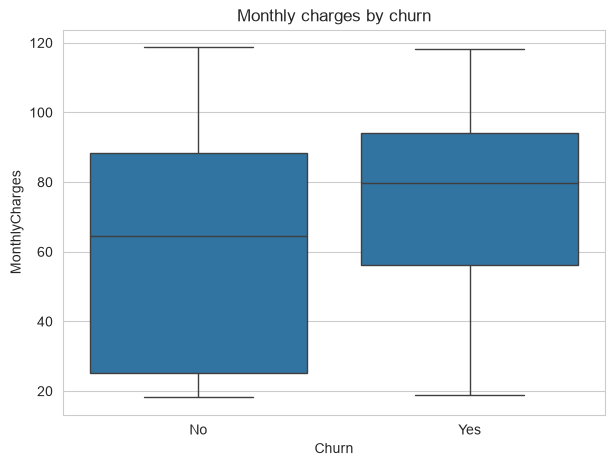

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly charges by churn")
plt.savefig("../results/charges_by_churn.png", bbox_inches="tight")
plt.show()

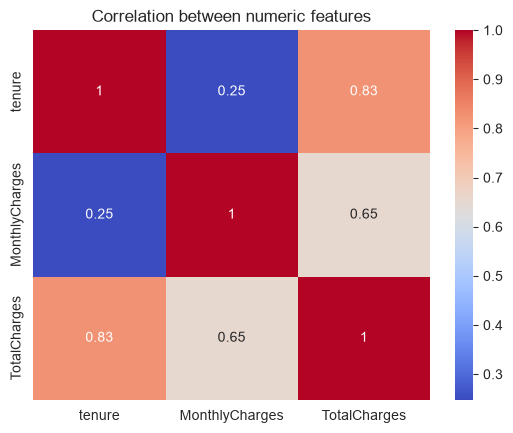

In [13]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.savefig("../results/correlation_heatmap.png", bbox_inches="tight")
plt.show()

TotalCharges is basically tenure times MonthlyCharges so its highly correlated with tenure, not adding a ton of new info but I'll leave it in.

## Feature engineering

Most columns are Yes/No or category text so they need to become numbers. Binary columns get label encoded. Columns with more than 2 categories get one hot encoded instead, otherwise the model would think one category is "bigger" than another which doesnt make sense here.

In [14]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

df.shape

(7043, 31)

## Train/test split and scaling

In [15]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((5634, 30), (1409, 30))

## Baseline model: Logistic Regression

Starting with Logistic Regression since its simple and gives a baseline for a more complex model to actually beat.

First run of this gave a convergence warning, turns out tenure/MonthlyCharges/TotalCharges are way bigger numbers than the 0/1 dummy columns which messes with the solver. Scaling fixes it.

In [16]:
scaler = StandardScaler()
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

    No churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8421710713270816


## Random Forest

Trying Random Forest next to see if it picks up on non linear stuff that Logistic Regression cant.

In [18]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

    No churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8408160892815624


## Comparing the two models

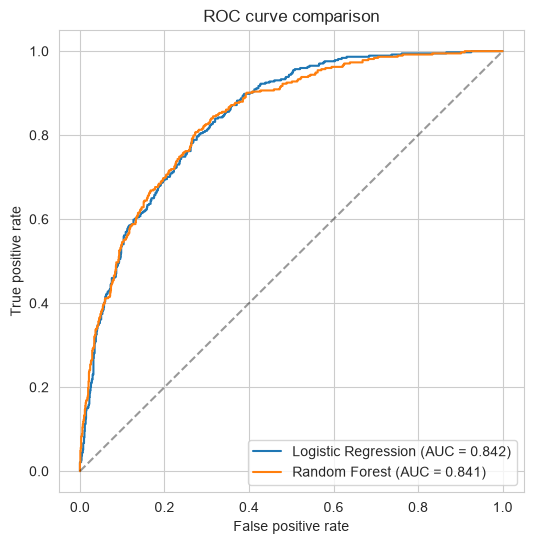

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve comparison")
plt.legend()
plt.savefig("../results/roc_comparison.png", bbox_inches="tight")
plt.show()

Both models end up really close on ROC-AUC. Guessing this is because contract type and tenure are already pretty linearly related to churn so Random Forest doesnt have much extra to find. Going with Logistic Regression since its way easier to explain anyway.

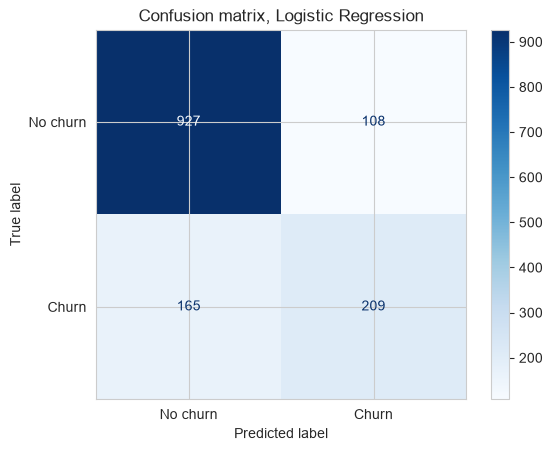

In [20]:
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"]).plot(cmap="Blues")
plt.title("Confusion matrix, Logistic Regression")
plt.savefig("../results/confusion_matrix.png", bbox_inches="tight")
plt.show()

## Feature importance

Using Random Forest's feature importances here since its useful for explaining results even though Logistic Regression is the model being used.

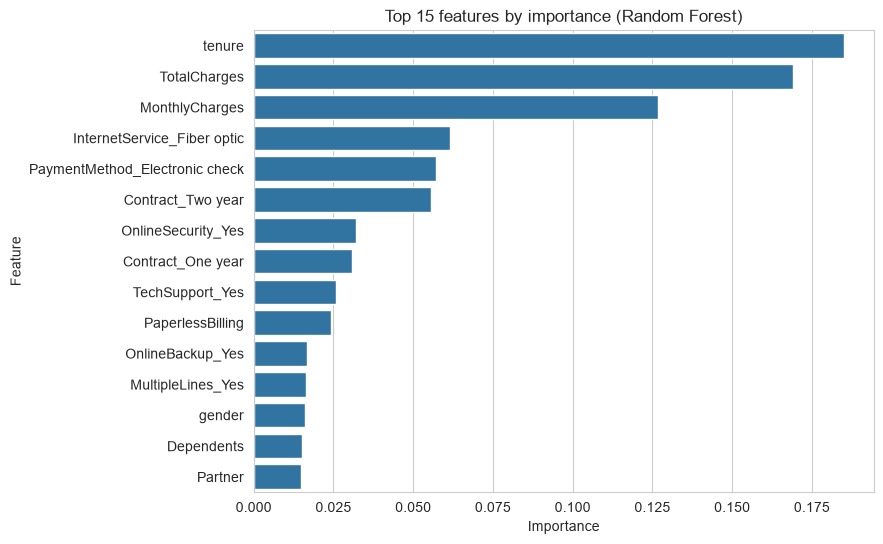

In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 features by importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("../results/feature_importance.png", bbox_inches="tight")
plt.show()

Tenure, charges and contract type are the biggest ones, matches what showed up in the EDA. Highest risk customers are new, on month to month, paying a lot.

## Improving recall

The baseline model only catches 56% of actual churners which isnt great, missing a churner is probably worse than wasting a retention offer on someone who wasnt going to leave anyway. Tried two things to fix this:

1. class_weight="balanced", makes the model care more about getting churn cases right during training
2. lowering the prediction threshold below the default 0.5

In [22]:
log_reg_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg_bal.fit(X_train_scaled, y_train)

y_pred_bal = log_reg_bal.predict(X_test_scaled)
y_proba_bal = log_reg_bal.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_bal, target_names=["No churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

    No churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8417318969748638


Recall jumps up a lot here, ROC-AUC barely moves though. Makes sense since ROC-AUC is about how well the model ranks churners vs non churners, class weighting doesnt change the ranking, just moves where the cutoff lands.

Next trying threshold tuning on the original model to see the full precision/recall tradeoff.

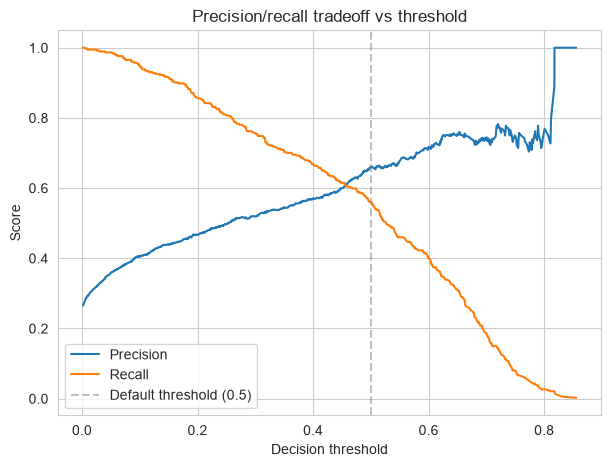

In [23]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision/recall tradeoff vs threshold")
plt.legend()
plt.savefig("../results/threshold_tuning.png", bbox_inches="tight")
plt.show()

In [24]:
threshold = 0.3
y_pred_thresh = (y_proba_lr >= threshold).astype(int)

print(classification_report(y_test, y_pred_thresh, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.89      0.75      0.81      1035
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



Threshold of 0.3 gets recall to 0.76, actually a bit lower than what class weighting got (0.78), and precision is a bit worse too. So class weighting wins here, not just simpler but actually better.

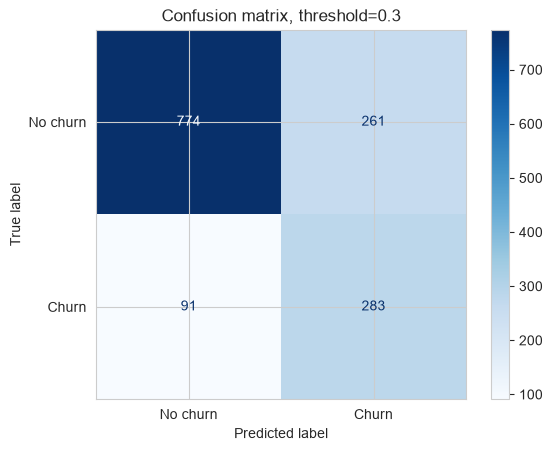

In [25]:
cm_thresh = confusion_matrix(y_test, y_pred_thresh)
ConfusionMatrixDisplay(cm_thresh, display_labels=["No churn", "Churn"]).plot(cmap="Blues")
plt.title(f"Confusion matrix, threshold={threshold}")
plt.savefig("../results/confusion_matrix_tuned.png", bbox_inches="tight")
plt.show()

## Conclusion

Both baseline models land around 0.84 ROC-AUC with recall around 0.53-0.56 at the default threshold, so they catch a bit over half of churners out of the box.

class_weight="balanced" got recall up to 0.78 (from 0.56), precision drops to 0.50 though. Threshold tuning to 0.3 got a similar but slightly worse result (0.76 recall). So class weighting is the better fix here.

Missing a churner is usually worse for a business than wasting a retention offer, so the class weighted model seems like the better one to actually use even with the lower precision.

Main churn signals are contract type, tenure and monthly charges. Simple takeaway, try to get month to month customers onto longer contracts and pay more attention to customers in their first few months.